# Assignment 3

## Learn an XOR Neural Network using gradient-based optimization

Author: Samuel Fredric Berg

Student ID: sb224sc

Date: 2026-04-19

Course: Deep Machine Learning 4DT908

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Function definitions

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))


def mse_derivative(y_true, y_pred):
    n = y_true.size
    return (2 / n) * (y_pred - y_true)

### Init training data

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([[0], [1], [1], [0]])

### Init random weights & train network

In [4]:
np.random.seed(42)

input_size = 2
hidden_size = 5
output_size = 1

weights_1 = 0.1 * np.random.randn(input_size, hidden_size)
biases_1 = np.zeros((1, hidden_size))
weights_2 = 0.1 * np.random.randn(hidden_size, output_size)
biases_2 = np.zeros((1, output_size))

learning_rate = 3.0
epochs = 5000
losses = []

for epoch_idx in range(epochs):
    z_1 = X @ weights_1 + biases_1
    a_1 = sigmoid(z_1)
    z_2 = a_1 @ weights_2 + biases_2
    a_2 = sigmoid(z_2)

    loss_val = mse(Y, a_2)
    losses.append(loss_val)

    if epoch_idx % 1000 == 0 or epoch_idx == epochs - 1:
        print(f"Epoch {epoch_idx}, Loss: {loss_val:.5f}")

    dz_2 = mse_derivative(Y, a_2) * sigmoid_derivative(z_2)
    dw_2 = a_1.T @ dz_2
    db_2 = np.sum(dz_2, axis=0, keepdims=True)

    dz_1 = dz_2 @ weights_2.T * sigmoid_derivative(z_1)
    dw_1 = X.T @ dz_1
    db_1 = np.sum(dz_1, axis=0, keepdims=True)

    weights_2 -= learning_rate * dw_2
    biases_2 -= learning_rate * db_2
    weights_1 -= learning_rate * dw_1
    biases_1 -= learning_rate * db_1

Epoch 0, Loss: 0.25300
Epoch 1000, Loss: 0.25000
Epoch 2000, Loss: 0.24999
Epoch 3000, Loss: 0.02343
Epoch 4000, Loss: 0.00095
Epoch 4999, Loss: 0.00043


### Evaluate network


Final outputs after training:
[[0.]
 [1.]
 [1.]
 [0.]]


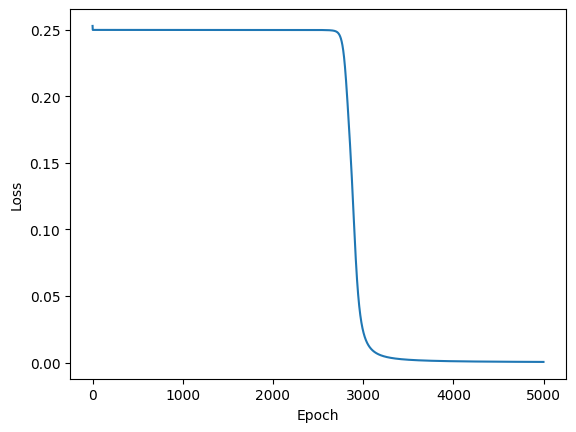

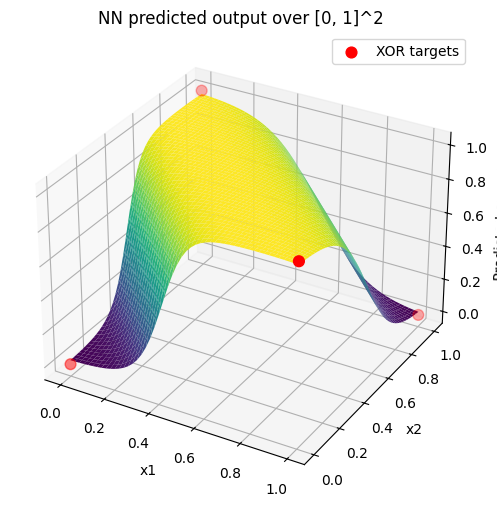

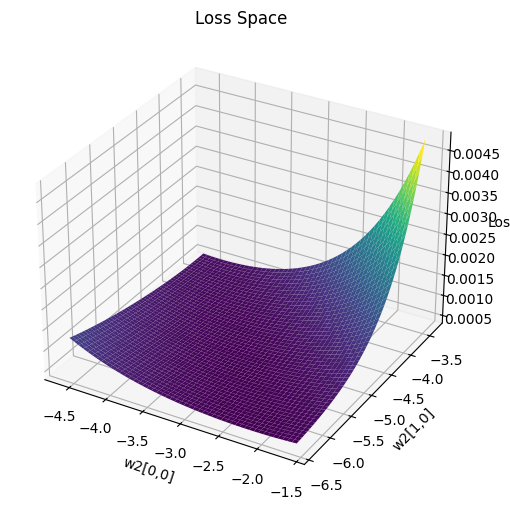

In [7]:
print("\nFinal outputs after training:")
z1 = X @ weights_1 + biases_1
a1 = sigmoid(z1)
z2 = a1 @ weights_2 + biases_2
a2 = sigmoid(z2)
print(np.round(a2))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

x1_range = np.linspace(0, 1, 50)
x2_range = np.linspace(0, 1, 50)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
X_grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])

a1_grid = sigmoid(X_grid @ weights_1 + biases_1)
a2_grid = sigmoid(a1_grid @ weights_2 + biases_2).reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x1_grid, x2_grid, a2_grid, cmap="viridis")
ax.scatter(
    X[:, 0], X[:, 1], Y.ravel(), color="red", s=60, zorder=5, label="XOR targets"
)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Predicted output")
ax.set_title("NN predicted output over [0, 1]^2")
ax.legend()
plt.show()

w_range = np.linspace(weights_2[0, 0] - 1.5, weights_2[0, 0] + 1.5, 50)
v_range = np.linspace(weights_2[1, 0] - 1.5, weights_2[1, 0] + 1.5, 50)
w0, w1 = np.meshgrid(w_range, v_range)
loss = np.zeros_like(w0)

for i in range(w0.shape[0]):
    for j in range(w0.shape[1]):
        w2_tmp = np.copy(weights_2)
        w2_tmp[0, 0] = w0[i, j]
        w2_tmp[1, 0] = w1[i, j]

        a1_tmp = sigmoid(X @ weights_1 + biases_1)
        a2_tmp = sigmoid(a1_tmp @ w2_tmp + biases_2)
        loss[i, j] = mse(Y, a2_tmp)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(w0, w1, loss, cmap="viridis")
ax.set_xlabel("w2[0,0]")
ax.set_ylabel("w2[1,0]")
ax.set_zlabel("Loss")
ax.set_title("Loss Space")
plt.show()

### Verify gradients with PyTorch autodiff

In [6]:
import torch

X_t = torch.tensor(X, dtype=torch.float64)
Y_t = torch.tensor(Y, dtype=torch.float64)

w1_t = torch.tensor(weights_1, dtype=torch.float64, requires_grad=True)
b1_t = torch.tensor(biases_1, dtype=torch.float64, requires_grad=True)
w2_t = torch.tensor(weights_2, dtype=torch.float64, requires_grad=True)
b2_t = torch.tensor(biases_2, dtype=torch.float64, requires_grad=True)

z1_t = X_t @ w1_t + b1_t
a1_t = torch.sigmoid(z1_t)
z2_t = a1_t @ w2_t + b2_t
a2_t = torch.sigmoid(z2_t)
loss_t = torch.mean((Y_t - a2_t) ** 2)

loss_t.backward()

z_1_v = X @ weights_1 + biases_1
a_1_v = sigmoid(z_1_v)
z_2_v = a_1_v @ weights_2 + biases_2
a_2_v = sigmoid(z_2_v)

dz_2_v = mse_derivative(Y, a_2_v) * sigmoid_derivative(z_2_v)
dw_2_manual = a_1_v.T @ dz_2_v
db_2_manual = np.sum(dz_2_v, axis=0, keepdims=True)
dz_1_v = dz_2_v @ weights_2.T * sigmoid_derivative(z_1_v)
dw_1_manual = X.T @ dz_1_v
db_1_manual = np.sum(dz_1_v, axis=0, keepdims=True)

print("Gradient verification:")
print(f"\tdw2 max abs diff: {np.max(np.abs(dw_2_manual - w2_t.grad.numpy())):.2e}")
print(f"\tdb2 max abs diff: {np.max(np.abs(db_2_manual - b2_t.grad.numpy())):.2e}")
print(f"\tdw1 max abs diff: {np.max(np.abs(dw_1_manual - w1_t.grad.numpy())):.2e}")
print(f"\tdb1 max abs diff: {np.max(np.abs(db_1_manual - b1_t.grad.numpy())):.2e}")

Gradient verification:
	dw2 max abs diff: 6.78e-21
	db2 max abs diff: 0.00e+00
	dw1 max abs diff: 5.42e-20
	db1 max abs diff: 8.13e-20


### Conclusion

The network successfully learned the XOR problem.
 
The network uses 2 input neurons, a hidden layer of 5 units, and 1 output neuron, all with sigmoid activations. Weights were initialised with small random values (scaled by 0.1) and biases at zero. Training ran for 5 000 epochs with a learning rate of 3.0 and mean-squared error (MSE) as the loss function.

As shown in the loss curve, the network made very little progress during the first ~3 000 epochs before converging rapidly. This is characteristic of gradient descent on non-convex loss landscapes.

The Gradient verification section showcases that the differences are very small (less than 1e-10), confirming that the analytical gradients are correct.